In [2]:
from nilearn import image
import numpy as np
import os.path as op
import pandas as pd
from nilearn.glm.first_level import make_first_level_design_matrix
import matplotlib.pyplot as plt

In [3]:
def get_fmri_data(subject, bids_folder='/shares/zne.uzh/multlearn/ds-mlearn'):

    runs = np.arange(1, 7)

    data = []

    for run in runs:
        fn = op.join(bids_folder, 'derivatives', 'fmriprep',
                      f'sub-{subject:02d}', 'func', 
                      f'sub-{subject:02d}_task-learn_run-{run}_space-T1w_desc-preproc_bold.nii')
    
        data.append(image.load_img(fn).get_fdata())

    return data


In [4]:
def get_template_image(subject, bids_folder='/mnt/d/data/ds-mlearn'):

    run = 1
    fn = op.join(bids_folder, 'derivatives', 'fmriprep',
                    f'sub-{subject:02d}', 'func', 
                    f'sub-{subject:02d}_task-learn_run-{run}_space-T1w_desc-preproc_bold.nii')
    
    return image.load_img(fn)

In [5]:
data = get_fmri_data(1)

In [6]:
import glob
from scipy import io
def get_rpe(subject,  bids_folder='/mnt/d/multlearn-sns/Modelling/Fitting/bestFittingVals'):
    template = op.join(bids_folder, f'sub-{subject:02d}', 'rpe*.mat')
    print(template)
    fn = glob.glob(template)
    print(fn)
    assert(len(fn) == 1)
    fn = fn[0]

    return pd.DataFrame(io.loadmat(fn)['rpe'],
                        index=pd.Index(np.arange(1, 7), name='run'),
                        columns=pd.Index(np.arange(1, 61), name='trial_nr')).stack().to_frame('rpe')
                   


In [7]:
def get_events(subject, bids_folder='/mnt/d/data'):

    runs = np.arange(1, 7)

    events = []

    for run in runs:
        fn = op.join(bids_folder,'ds-mlearn', 'derivatives', 'fmriprep',
                      f'sub-{subject:02d}', 'func', 
                      f'sub-{subject:02d}_task-learn_run-{run}_events.tsv')
        
        e = pd.read_csv(fn, sep='\t').sort_values('onset').drop(columns='runType')
        e['trial_nr'] = e['trial_nr'].ffill().astype(int)
        #e['runType'] = e['runType'].ffill()
        e = e.set_index(['trial_nr', 'trial_type'])    
    
        events.append(e)
    fn2 = op.join(
        bids_folder,
        "sourcedata",
        "behavior",
        f"{subject:02d}",
        f"participant{subject:02d}_savedValues.csv",
    )

    events = pd.concat(events, keys=runs, names=["run"])
    stimulus_info = (
        pd.read_csv(
            fn2,
            usecols=["trialNumber", "runNumber", "visual"],
        )
        .rename(columns={"trialNumber": "trial_nr", "runNumber": "run"})
        .set_index(['run', 'trial_nr'])
        .sort_index()
    )
    
    events['visual_stimulus'] = np.repeat(stimulus_info['visual'].map(lambda x: f'stimulus {x+1}').values, 2)

    events = events.join(get_rpe(subject))

    return events


In [8]:
events = get_events(1)

/mnt/d/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-01/rpe*.mat
['/mnt/d/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-01/rpePearceExtra.mat']


In [11]:
print(events[40:60])

                              onset  duration visual_stimulus       rpe
run trial_nr trial_type                                                
1   21       choice      167.906970  1.570683      stimulus 1  0.152393
             feedback    171.554844  1.000000      stimulus 1  0.152393
    22       choice      174.821858  2.211932      stimulus 3 -0.180266
             feedback    178.805844  1.000000      stimulus 3 -0.180266
    23       choice      182.235812  2.542870      stimulus 1  0.094934
             feedback    186.472758  1.000000      stimulus 1  0.094934
    24       choice      190.134337  2.683895      stimulus 2  0.818992
             feedback    194.000902  1.000000      stimulus 2  0.818992
    25       choice      199.331851  2.631979      stimulus 1 -0.116453
             feedback    202.947100  1.000000      stimulus 1 -0.116453
    26       choice      208.335739  1.861178      stimulus 3  0.171344
             feedback    212.832629  1.000000      stimulus 3  0

: 

In [9]:
tr = 2.3
n = 222
runs = np.arange(1, 7)
frametimes = np.linspace(tr/2., (n - .5)*tr, n)

In [16]:
feedback_onsets = events.xs('feedback', 0, 'trial_type')

rpe_onsets = feedback_onsets.copy()
rpe_onsets['trial_type'] = 'rpe'

rpe_onsets['modulation'] = rpe_onsets['rpe'].groupby('run').transform(lambda x: x-x.mean())

feedback_onsets['trial_type'] = 'feedback'
feedback_onsets['modulation'] = 1.

glm_onsets = pd.concat((rpe_onsets, feedback_onsets))

glm_dm = [make_first_level_design_matrix(frametimes, glm_onsets.loc[run, slice(None)], oversampling=100.,
                                        drift_order=0,
                                        drift_model=None).drop('constant', axis=1) for run in runs]

print(glm_dm)

A 'modulation' column was found in the given events data and is used.
A 'modulation' column was found in the given events data and is used.
A 'modulation' column was found in the given events data and is used.
A 'modulation' column was found in the given events data and is used.
A 'modulation' column was found in the given events data and is used.
A 'modulation' column was found in the given events data and is used.
[        feedback       rpe
1.15    0.000000  0.000000
3.45    0.000000  0.000000
5.75    0.000000  0.000000
8.05    0.000131 -0.000068
10.35   0.101280 -0.052466
...          ...       ...
500.25  0.057093  0.035696
502.55 -0.039227 -0.006961
504.85 -0.053088 -0.016220
507.15 -0.033561 -0.011041
509.45 -0.015066 -0.005086

[222 rows x 2 columns],         feedback       rpe
1.15    0.000000  0.000000
3.45    0.000000  0.000000
5.75    0.000000  0.000000
8.05    0.000131  0.000069
10.35   0.101280  0.053640
...          ...       ...
500.25  0.057093 -0.028037
502.55 -0.0392

C:\Users\ellac\AppData\Local\Temp\ipykernel_28204\3465858600.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feedback_onsets['trial_type'] = 'feedback'
C:\Users\ellac\AppData\Local\Temp\ipykernel_28204\3465858600.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feedback_onsets['modulation'] = 1.
c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:166: UserWarning: The following unexpected columns in events data will be ignored: visual_s

In [17]:
feedback_onsets

onset  duration visual_stimulus       rpe trial_type  \
run trial_nr                                                              
1   1           7.222282       1.0      stimulus 1 -0.500000   feedback   
    2          15.242718       1.0      stimulus 2 -0.500000   feedback   
    3          23.062699       1.0      stimulus 3  0.500000   feedback   
    4          31.765834       1.0      stimulus 1 -0.500000   feedback   
    5          38.815954       1.0      stimulus 3  0.500000   feedback   
...                  ...       ...             ...       ...        ...   
6   56        459.820987       1.0      stimulus 1  0.181146   feedback   
    57        468.005009       1.0      stimulus 3  0.097516   feedback   
    58        475.647851       1.0      stimulus 2  0.057873   feedback   
    59        483.903012       1.0      stimulus 3  0.212302   feedback   
    60        491.389802       1.0      stimulus 1 -0.986463   feedback   

              modulation  
run trial_nr              
1   1                1.0  
    2                1.0  
    3                1.0  
    4                1.0  
    5                1.0  
...                  ...  
6   56               1.0  
    57               1.0  
    58               1.0  
    59               1.0  
    60               1.0  

[360 rows x 6 columns]

<Axes: >

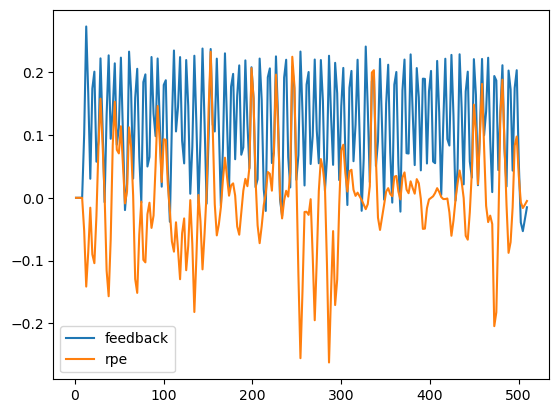

In [18]:
glm_dm[0].plot()

In [112]:
events

onset  duration visual_stimulus       rpe
run trial_nr trial_type                                                
1   1        choice        3.477700  2.226177      stimulus 1 -0.500000
             feedback      7.222282  1.000000      stimulus 1 -0.500000
    2        choice       11.100398  1.879317      stimulus 2 -0.500000
             feedback     15.242718  1.000000      stimulus 2 -0.500000
    3        choice       19.372291  2.399425      stimulus 3  0.500000
...                             ...       ...             ...       ...
6   58       feedback    475.647851  1.000000      stimulus 2  0.057873
    59       choice      479.561975  1.873389      stimulus 3  0.212302
             feedback    483.903012  1.000000      stimulus 3  0.212302
    60       choice      487.568466  1.803883      stimulus 1 -0.986463
             feedback    491.389802  1.000000      stimulus 1 -0.986463

[720 rows x 4 columns]

In [96]:
tr = 2.3
n = 222
runs = np.arange(1, 7)
frametimes = np.linspace(tr/2., (n - .5)*tr, n)
events['onset'] = ((events['onset']+tr/2.) // 2.3) * 2.3

events['duration'] = 0.0
events['trial_type'] = events['visual_stimulus']

dm = [make_first_level_design_matrix(frametimes, events.loc[run, slice(None), 'choice'], hrf_model='fir', oversampling=100.,
                                        drift_order=0,
                                        drift_model=None).drop('constant', axis=1) for run in runs]

dm = pd.concat(dm, keys=runs, names=['run']).fillna(0)
dm.columns = [c.replace('_delay_0', '') for c in dm.columns]
dm /= dm.max()
print(dm)

            stimulus 1  stimulus 2  stimulus 3
run                                           
1   1.15           0.0         0.0         0.0
    3.45           1.0         0.0         0.0
    5.75           0.0         0.0         0.0
    8.05           0.0         0.0         0.0
    10.35          0.0         1.0         0.0
...                ...         ...         ...
6   500.25         0.0         0.0         0.0
    502.55         0.0         0.0         0.0
    504.85         0.0         0.0         0.0
    507.15         0.0         0.0         0.0
    509.45         0.0         0.0         0.0

[1332 rows x 3 columns]


c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:141: UserWarning: The following conditions contain events with null duration:
stimulus 1, stimulus 2, stimulus 3.
  warnings.warn(
c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:166: UserWarning: The following unexpected columns in events data will be ignored: visual_stimulus, rpe
  warnings.warn(
c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:141: UserWarning: The following conditions contain events with null duration:
stimulus 2, stimulus 1, stimulus 3.
  warnings.warn(
c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\nilearn\glm\first_level\experimental_paradigm.py:166: UserWarning: The following unexpected columns in events data will be ignored: visual_stimulus, rpe
  warnings.warn(
c:\Users\ellac\anaconda3\env

In [81]:
base_dir = 'D:\data\ds-mlearn\derivatives\glmsingle'

import os

if not op.exists(base_dir):
    os.makedirs(base_dir)

In [82]:
from glmsingle import GLM_single

In [97]:
X = [dm.loc[run].values for run in runs]

# create a directory for saving GLMsingle outputs

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 1
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [0, 0, 0, 1]

opt['extra_regressors'] = [cf.values for cf in glm_dm]

print(opt)
# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

results_glmsingle = glmsingle_obj.fit(
    X,
    data,
    0.6,
    2.3,
    outputdir=base_dir)

betas = results_glmsingle['typed']['betasmd']
betas = image.new_img_like(get_template_image(1), betas)


{'wantlibrary': 1, 'wantglmdenoise': 1, 'wantfracridge': 1, 'wantfileoutputs': [0, 0, 0, 1], 'extra_regressors': [array([[ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 5.95826672e-04,  8.42517388e-05],
       [ 2.61546149e-02,  3.69834364e-03],
       [ 3.64717688e-02,  5.15722118e-03],
       [ 1.45521770e-02,  2.05772294e-03],
       [-2.05000987e-03, -3.89228269e-04],
       [ 1.93266629e-02, -1.62653041e-03],
       [ 3.16608820e-02, -1.60157191e-03],
       [ 1.28759426e-02, -8.03235599e-04],
       [ 2.26736424e-02, -5.07195092e-03],
       [ 2.93833697e-02, -6.86370593e-03],
       [ 9.67113320e-03, -2.68081928e-03],
       [-4.33808893e-03,  4.48594109e-04],
       [ 1.84888146e-02, -3.68928787e-03],
       [ 3.14016456e-02, -6.07010101e-03],
       [ 1.28056535e-02, -2.51795353e-03],
       [ 2.26593283e-02, -6.48583443e-03],
       [ 2.93787065e-02, -8.61432019e-03],
       [ 1.02655901e-02, -

c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\sklearn\mixture\_base.py:268: ConvergenceWarning: Initialization 3 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 0.13065220395558969 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 3/3 [03:54<00:00, 78.04s/it]


*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



...


*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 3/3 [00:52<00:00, 17.34s/it]


*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 3/3 [14:57<00:00, 299.33s/it]



*** Saving results to D:\data\ds-mlearn\derivatives\glmsingle\TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***



In [84]:
from nilearn import plotting

In [85]:
results_glmsingle['typed'].keys()

dict_keys(['HRFindex', 'HRFindexrun', 'glmbadness', 'pcvoxels', 'pcnum', 'xvaltrend', 'noisepool', 'pcregressors', 'betasmd', 'R2', 'R2run', 'rrbadness', 'FRACvalue', 'scaleoffset', 'meanvol'])

c:\Users\ellac\anaconda3\envs\multilearn-decoding\lib\site-packages\nilearn\_utils\niimg.py:61: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(


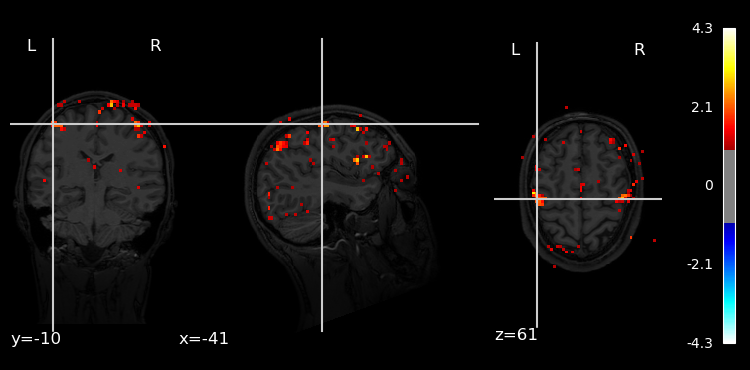

In [98]:
t1w = 'D:/data/ds-mlearn/derivatives/fmriprep/sub-01/anat/sub-01_desc-preproc_T1w.nii.gz'
r2 = image.new_img_like(get_template_image(1), results_glmsingle['typea']['onoffR2'])

plotting.plot_stat_map(r2, t1w, threshold=1.)

In [102]:
results_glmsingle['typea'].keys()

dict_keys(['onoffR2', 'meanvol', 'betasmd'])

In [108]:
betas.to_filename(op.join(base_dir, 'sub-01','betas_01.nii'))

In [1]:
import neuropythy as ny